<a href="https://colab.research.google.com/github/aditya2003desai-gif/literate-octo-doodle2/blob/main/Pandemic_Decision_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandemic Decision Support System

## Objective:
To analyze health and behavioral data to predict pandemic risk and provide decision-based insights for future outbreak management.

## Problem Statement:
Healthcare systems struggle to convert raw health data into actionable decisions during pandemics.

## Approach:
We use machine learning + data analysis to predict risk and suggest decisions.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Covid_Dataset[1].csv')  # use your exact file name
df.head()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Breathing Problem                        5434 non-null   object
 1   Fever                                    5434 non-null   object
 2   Dry Cough                                5434 non-null   object
 3   Sore throat                              5434 non-null   object
 4   Running Nose                             5434 non-null   object
 5   Asthma                                   5434 non-null   object
 6   Chronic Lung Disease                     5434 non-null   object
 7   Headache                                 5434 non-null   object
 8   Heart Disease                            5434 non-null   object
 9   Diabetes                                 5434 non-null   object
 10  Hyper Tension                            5434 non-null   obj

In [ ]:
df.columns

Index(['Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat',
       'Running Nose', 'Asthma', 'Chronic Lung Disease', 'Headache',
       'Heart Disease', 'Diabetes', 'Hyper Tension', 'Fatigue ',
       'Gastrointestinal ', 'Abroad travel', 'Contact with COVID Patient',
       'Attended Large Gathering', 'Visited Public Exposed Places',
       'Family working in Public Exposed Places', 'Wearing Masks',
       'Sanitization from Market', 'COVID-19'],
      dtype='object')

In [ ]:
for col in df.columns:
    print(col, df[col].unique())

Breathing Problem ['Yes' 'No']
Fever ['Yes' 'No']
Dry Cough ['Yes' 'No']
Sore throat ['Yes' 'No']
Running Nose ['Yes' 'No']
Asthma ['No' 'Yes']
Chronic Lung Disease ['No' 'Yes']
Headache ['No' 'Yes']
Heart Disease ['No' 'Yes']
Diabetes ['Yes' 'No']
Hyper Tension ['Yes' 'No']
Fatigue  ['Yes' 'No']
Gastrointestinal  ['Yes' 'No']
Abroad travel ['No' 'Yes']
Contact with COVID Patient ['Yes' 'No']
Attended Large Gathering ['No' 'Yes']
Visited Public Exposed Places ['Yes' 'No']
Family working in Public Exposed Places ['Yes' 'No']
Wearing Masks ['No']
Sanitization from Market ['No']
COVID-19 ['Yes' 'No']


In [ ]:
df.columns = df.columns.str.strip()
df.replace({'Yes':1, 'No':0}, inplace=True)

/tmp/ipykernel_535/3136365401.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes':1, 'No':0}, inplace=True)


In [ ]:
df.isnull().sum()


,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [ ]:
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df.replace({'Yes':1, 'No':0}, inplace=True)

/tmp/ipykernel_535/2596695088.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        5434 non-null   int64
 1   Fever                                    5434 non-null   int64
 2   Dry Cough                                5434 non-null   int64
 3   Sore throat                              5434 non-null   int64
 4   Running Nose                             5434 non-null   int64
 5   Asthma                                   5434 non-null   int64
 6   Chronic Lung Disease                     5434 non-null   int64
 7   Headache                                 5434 non-null   int64
 8   Heart Disease                            5434 non-null   int64
 9   Diabetes                                 5434 non-null   int64
 10  Hyper Tension                            5434 non-null   int64
 11  Fati

In [ ]:
df.duplicated().sum()


np.int64(4968)

FINAL DATA PREPARATION

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipykernel_535/242626680.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
df.replace({'Yes':1, 'No':0}, inplace=True)

In [ ]:
df.isnull().sum()

,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [ ]:
df = df.apply(pd.to_numeric)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 466 entries, 0 to 5325
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        466 non-null    int64
 1   Fever                                    466 non-null    int64
 2   Dry Cough                                466 non-null    int64
 3   Sore throat                              466 non-null    int64
 4   Running Nose                             466 non-null    int64
 5   Asthma                                   466 non-null    int64
 6   Chronic Lung Disease                     466 non-null    int64
 7   Headache                                 466 non-null    int64
 8   Heart Disease                            466 non-null    int64
 9   Diabetes                                 466 non-null    int64
 10  Hyper Tension                            466 non-null    int64
 11  Fatigue   

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,1,1,1,1,1,0,0,0,0,1,...,1,1,0,1,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,0,...,1,0,0,0,1,1,0,0,0,1
2,1,1,1,1,1,1,1,1,0,1,...,1,1,1,0,0,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,...,0,0,1,0,1,1,0,0,0,1
4,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,1,0,0,0,1


In [ ]:
EDA (Exploratory Data Analysis)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

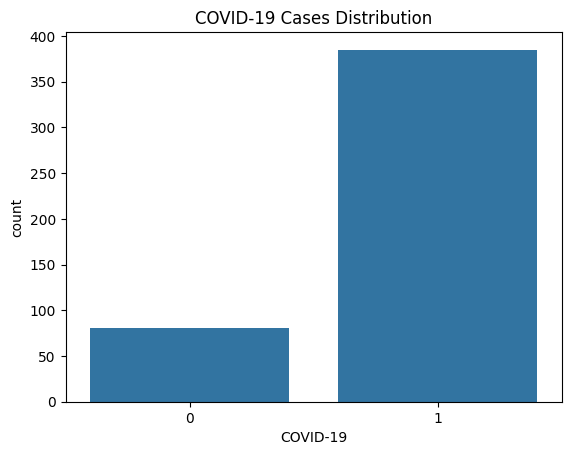

In [ ]:
sns.countplot(x='COVID-19', data=df)
plt.title("COVID-19 Cases Distribution")
plt.show()

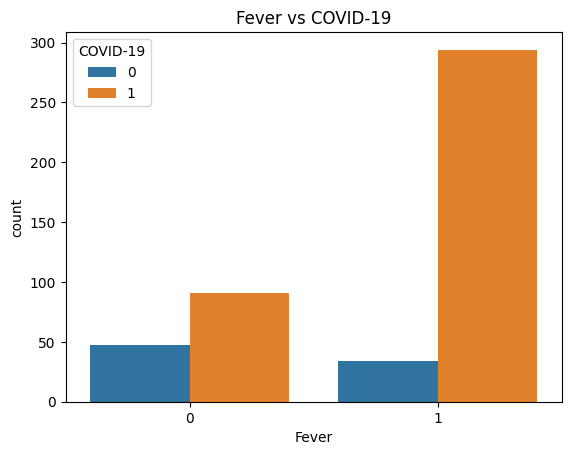

In [ ]:
sns.countplot(x='Fever', hue='COVID-19', data=df)
plt.title("Fever vs COVID-19")
plt.show()

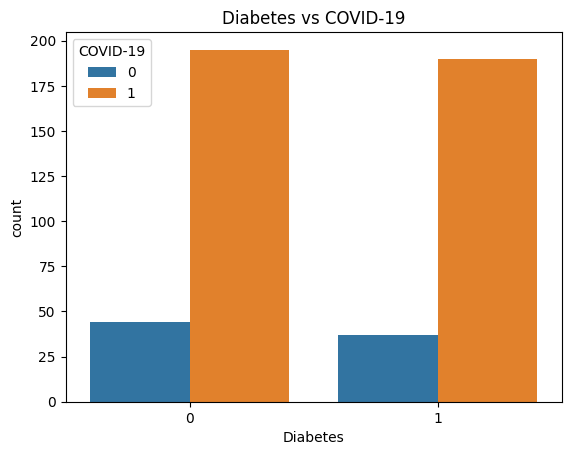

In [ ]:
sns.countplot(x='Diabetes', hue='COVID-19', data=df)
plt.title("Diabetes vs COVID-19")
plt.show()

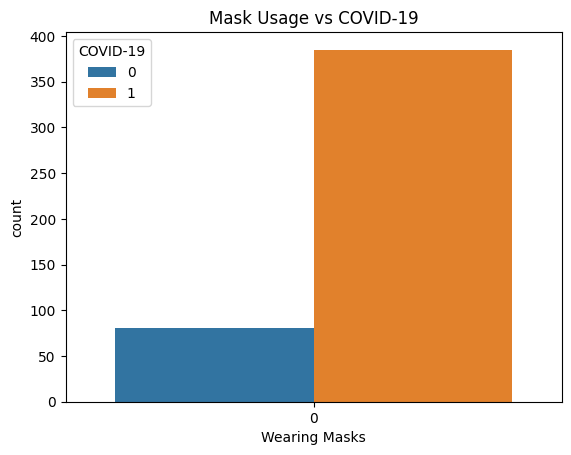

In [ ]:
sns.countplot(x='Wearing Masks', hue='COVID-19', data=df)
plt.title("Mask Usage vs COVID-19")
plt.show()

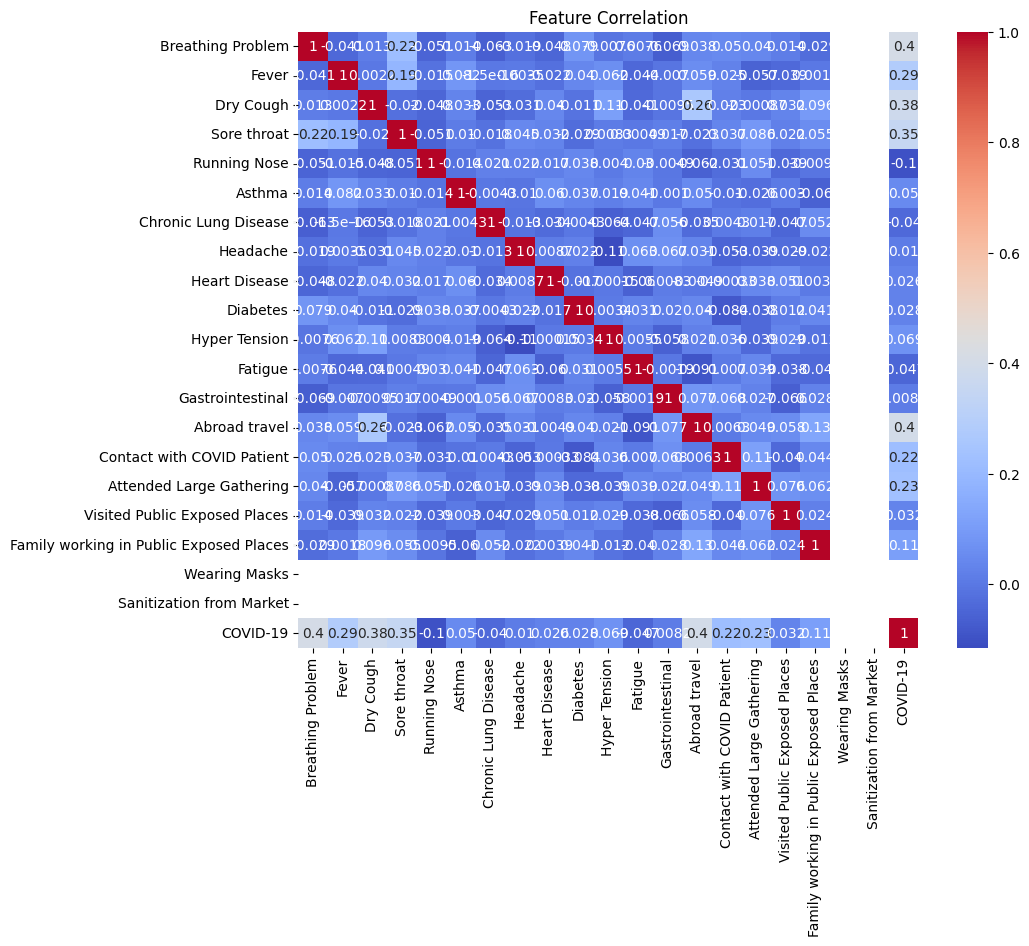

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [ ]:
Model Building

In [ ]:
X = df.drop('COVID-19', axis=1)
y = df['COVID-19']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9042553191489362


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[14  5]
 [ 4 71]]


In [ ]:
Prediction system

In [ ]:
def predict_risk():
    print("Enter details (0 = No, 1 = Yes):\n")

    user_input = []

    for col in X.columns:
        val = int(input(f"{col}: "))
        user_input.append(val)

    # Convert to DataFrame
    import pandas as pd
    input_df = pd.DataFrame([user_input], columns=X.columns)

    # Prediction
    prediction = model.predict(input_df)[0]

    # Output
    if prediction == 1:
        print("\n⚠ HIGH RISK of infection")
    else:
        print("\n✅ LOW RISK of infection")

In [ ]:
predict_risk()
111


Enter details (0 = No, 1 = Yes):

Breathing Problem: 1
Fever: 1
Dry Cough: 1
Sore throat: 1
Running Nose: 1
Asthma: 1
Chronic Lung Disease: 1
Headache: 1
Heart Disease: 1
Diabetes: 1
Hyper Tension: 1
Fatigue: 1
Gastrointestinal: 1
Abroad travel: 1
Contact with COVID Patient: 1
Attended Large Gathering: 1
Visited Public Exposed Places: 1
Family working in Public Exposed Places: 1
Wearing Masks: 1
Sanitization from Market: 1

⚠ HIGH RISK of infection


11

In [ ]:
def predict_risk():
    print("Enter details (0 = No, 1 = Yes):\n")

    user_input = []

    for col in X.columns:
        val = int(input(f"{col}: "))
        user_input.append(val)

    import pandas as pd
    input_df = pd.DataFrame([user_input], columns=X.columns)

    # Prediction
    prediction = model.predict(input_df)[0]

    # Probability (SAFE WAY)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(input_df)[0][1]
        print("Risk Probability:", round(prob * 100, 2), "%")
    else:
        print("Probability not supported by model")
        prob = 0

    # Risk Level
    if prob > 0.7:
        print("⚠ HIGH RISK")
    elif prob > 0.4:
        print("⚠ MEDIUM RISK")
    else:
        print("✅ LOW RISK")

In [ ]:
predict_risk()

Enter details (0 = No, 1 = Yes):

Breathing Problem: 0
Fever: 0
Dry Cough: 0
Sore throat: 0
Running Nose: 0
Asthma: 0
Chronic Lung Disease: 0
Headache: 0
Heart Disease: 0
Diabetes: 0
Hyper Tension: 0
Fatigue: 0
Gastrointestinal: 0
Abroad travel: 0
Contact with COVID Patient: 0
Attended Large Gathering: 0
Visited Public Exposed Places: 0
Family working in Public Exposed Places: 0
Wearing Masks: 0
Sanitization from Market: 0
Risk Probability: 0.0 %
✅ LOW RISK


In [ ]:
def predict_risk():
    print("Enter details (0 = No, 1 = Yes):\n")

    user_input = []

    for col in X.columns:
        val = int(input(f"{col}: "))
        user_input.append(val)

    import pandas as pd
    input_df = pd.DataFrame([user_input], columns=X.columns)

    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    print("\nRisk Probability:", round(prob * 100, 2), "%")

    # Risk Levels + Decisions
    if prob > 0.7:
        print("⚠ HIGH RISK")
        print("👉 Action: Immediate testing, isolation, medical consultation")

    elif prob > 0.4:
        print("⚠ MEDIUM RISK")
        print("👉 Action: Monitor symptoms, avoid public places, wear mask")

    else:
        print("✅ LOW RISK")
        print("👉 Action: Maintain precautions, no immediate concern")

In [ ]:
corr = df.corr()['COVID-19'].sort_values(ascending=False)
print(corr)

COVID-19                                   1.000000
Breathing Problem                          0.403773
Abroad travel                              0.397728
Dry Cough                                  0.380792
Sore throat                                0.350346
Fever                                      0.285435
Attended Large Gathering                   0.225844
Contact with COVID Patient                 0.220047
Family working in Public Exposed Places    0.108145
Hyper Tension                              0.069233
Asthma                                     0.049655
Visited Public Exposed Places              0.031770
Diabetes                                   0.027837
Heart Disease                              0.026345
Headache                                   0.010092
Gastrointestinal                           0.008161
Chronic Lung Disease                      -0.039639
Fatigue                                   -0.046569
Running Nose                              -0.100208
Wearing Mask

In [ ]:
print("\nTop Risk Factors:")
print(corr.head(5))


Top Risk Factors:
COVID-19             1.000000
Breathing Problem    0.403773
Abroad travel        0.397728
Dry Cough            0.380792
Sore throat          0.350346
Name: COVID-19, dtype: float64


In [ ]:
high_risk = df[df['COVID-19'] == 1]

mask_effect = high_risk['Wearing Masks'].mean()

print("\nMask Usage in High Risk Cases:", mask_effect)


Mask Usage in High Risk Cases: 0.0


In [ ]:
predict_risk()

Enter details (0 = No, 1 = Yes):

Breathing Problem: 1
Fever: 1
Dry Cough: 1
Sore throat: 1
Running Nose: 0
Asthma: 1
Chronic Lung Disease: 1
Headache: 0
Heart Disease: 1
Diabetes: 1
Hyper Tension: 0
Fatigue: 1
Gastrointestinal: 0
Abroad travel: 1
Contact with COVID Patient: 1
Attended Large Gathering: 1
Visited Public Exposed Places: 0
Family working in Public Exposed Places: 1
Wearing Masks: 1
Sanitization from Market: 1

Risk Probability: 100.0 %
⚠ HIGH RISK
👉 Action: Immediate testing, isolation, medical consultation
